# ENTRENAMIENTO DE RED NEURONAL CON PYTORCH PARA CLASIFICACIÓN DE AGUA POTABLE

## DATASET : [KAGGLE](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS EL DATASET

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityakadiwal/water-potability")

print("Path to dataset files:", path)

100%|██████████| 251k/251k [00:00<00:00, 87.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3


In [3]:
!ls /root/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3

water_potability.csv


In [4]:
PATH_CSV = path + "/water_potability.csv"

In [5]:
df = pd.read_csv(PATH_CSV)
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# EDA

In [6]:
df.dtypes

,0
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


In [7]:
df.shape

(3276, 10)

In [8]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


# IMPUTACIÓN DE DATOS FALTANTES

In [9]:
for col in ['ph','Sulfate','Trihalomethanes']:
  df[col].fillna(df[col].mean(),inplace=True)

/tmp/ipykernel_597/1823010799.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)


In [10]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


## IDENTIFICAMOS VARIABEL X Y Y

In [11]:
X = df.iloc[:,0:9].values
y = df.iloc[:,9].values

# ESCALAMOS LOS DATOS

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

## DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# CONVERTIR A TENSORES EL DATASET

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# CREAMOS RED NEURONAL CON PYTORCH

In [16]:
class RNN(nn.Module):
  def __init__(self):
    super(RNN,self).__init__()
    self.entrada = nn.Linear(9,5)
    self.oculta1 = nn.Linear(5,5)
    self.salida = nn.Linear(5,1)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.relu(self.entrada(x))
    x = self.relu(self.oculta1(x))
    x = self.sigmoid(self.salida(x))
    return x

# CONFIGURAMOS LA RED CON UN OPTIMIZADOR CON PYTORCH

In [17]:
modelo = RNN()
criterion = nn.BCELoss()
optimizer = optim.RMSprop(modelo.parameters(),lr=0.01)

# ENTRENAMOS LA RED NEURONAL CON PYTORCH

In [18]:
epochs = 100
batch_size = 30
losses = []
accuracies = []

for epoch in range(epochs):
  modelo.train()
  running_loss = 0.0
  correct = 0
  for i in range(0,len(X_train_tensor),batch_size):
    X_batch = X_train_tensor[i:i+batch_size]
    y_batch = y_train_tensor[i:i+batch_size].unsqueeze(1)

    #realizamos predicción
    outputs = modelo(X_batch)

    #calculamos loss
    loss = criterion(outputs,y_batch)
    running_loss += loss.item()

    #limpiamos la gradientes
    optimizer.zero_grad()

    #propagamos la gradiente
    loss.backward()

    #actualizamos los pesos
    optimizer.step()

  #calculamos la perdida media y la precisión
  epoch_loss = running_loss / (len(X_train_tensor) / batch_size)
  losses.append(epoch_loss)

  #evaluamos el modelo en el conjunto de entrenamiento
  modelo.eval()
  with torch.no_grad():
    outputs = modelo(X_train_tensor)
    predicted = (outputs > 0.5).float()
    correct += (predicted.eq(y_train_tensor.unsqueeze(1))).sum().item()

  accuracy = correct / len(y_train_tensor)
  accuracies.append(accuracy)

  print(f'Epoch [{epoch + 1}/{epochs}], Loss : {epoch_loss:.4f} , Accuracy : {accuracy * 100:.2f}%')

Epoch [1/100], Loss : 0.6700 , Accuracy : 61.64%
Epoch [2/100], Loss : 0.6499 , Accuracy : 63.55%
Epoch [3/100], Loss : 0.6356 , Accuracy : 64.85%
Epoch [4/100], Loss : 0.6238 , Accuracy : 65.84%
Epoch [5/100], Loss : 0.6167 , Accuracy : 66.53%
Epoch [6/100], Loss : 0.6130 , Accuracy : 66.76%
Epoch [7/100], Loss : 0.6106 , Accuracy : 66.72%
Epoch [8/100], Loss : 0.6083 , Accuracy : 66.95%
Epoch [9/100], Loss : 0.6071 , Accuracy : 66.91%
Epoch [10/100], Loss : 0.6060 , Accuracy : 66.95%
Epoch [11/100], Loss : 0.6058 , Accuracy : 67.10%
Epoch [12/100], Loss : 0.6058 , Accuracy : 66.98%
Epoch [13/100], Loss : 0.6052 , Accuracy : 67.10%
Epoch [14/100], Loss : 0.6051 , Accuracy : 67.06%
Epoch [15/100], Loss : 0.6051 , Accuracy : 66.91%
Epoch [16/100], Loss : 0.6048 , Accuracy : 66.95%
Epoch [17/100], Loss : 0.6048 , Accuracy : 67.25%
Epoch [18/100], Loss : 0.6044 , Accuracy : 67.14%
Epoch [19/100], Loss : 0.6044 , Accuracy : 67.29%
Epoch [20/100], Loss : 0.6041 , Accuracy : 67.25%
Epoch [21

# GRAFICA DE ACCURACY Y LOSS DE ENTRENAMIENTO

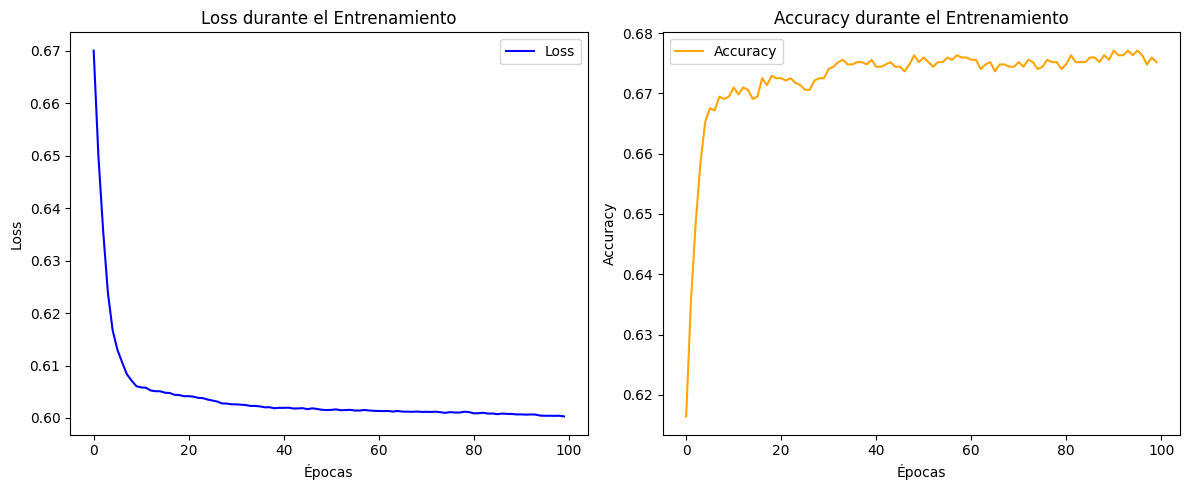

In [19]:
# Graficar loss y accuracy
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(losses, label='Loss', color='blue')
plt.title('Loss durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy', color='orange')
plt.title('Accuracy durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# VALIDAMOS EL MODELO CON PYTORCH

In [20]:
#evaluamos el modelo en el conjunto de entrenamiento
modelo.eval()
with torch.no_grad():
  X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

  test_outputs = modelo(X_test_tensor)
  predicted_test = (test_outputs > 0.5).float()
  correct_test = (predicted_test.eq(y_test_tensor)).sum().item()
  accuracy_test = correct_test / len(y_test_tensor)

print(f'Test Accuracy : {accuracy_test * 100:.2f}%')

Test Accuracy : 66.16%


# MATRIZ DE CONFUSIÓN

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
# Crear la matriz de confusión
y_test_labels = y_test_tensor.numpy()  # Convertir a numpy para sklearn
predicted_labels = predicted_test.numpy()  # Convertir a numpy para sklearn

cm = confusion_matrix(y_test_labels, predicted_labels)
cm

array([[349,  51],
       [171,  85]])

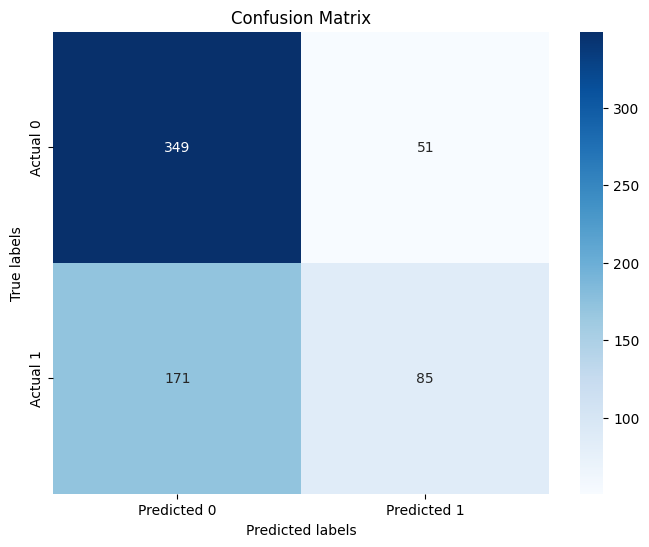

In [22]:
# Visualizar la matriz de confusión
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Predicted 0', 'Predicted 1'],
             yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()